In [1]:
import pandas as pd
import numpy as np
print("Libraries loaded")

Libraries loaded


In [3]:
traffic_df = pd.read_csv('Dataset_Uber Traffic.csv')
weather_df = pd.read_csv('weather_hyderabad.csv')
events_df = pd.read_csv('events_hyderabad.csv')

print("Traffic shape:", traffic_df.shape)
print("Weather shape:", weather_df.shape)
print("Events shape:", events_df.shape)

traffic_df.head()

Traffic shape: (48120, 4)
Weather shape: (14569, 5)
Events shape: (5, 3)


,DateTime,Junction,Vehicles,ID
0,01/11/15 0:00,1,15,20151101001
1,01/11/15 1:00,1,13,20151101011
2,01/11/15 2:00,1,10,20151101021
3,01/11/15 3:00,1,7,20151101031
4,01/11/15 4:00,1,9,20151101041


In [4]:
# Check data types and info
print(traffic_df.info())
print("\nData types:\n", traffic_df.dtypes)

# DateTime is object now, convert to datetime
traffic_df['DateTime'] = pd.to_datetime(traffic_df['DateTime'])
weather_df['DateTime'] = pd.to_datetime(weather_df['DateTime'])

print("\nAfter conversion:")
print(traffic_df.dtypes)
print(traffic_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None

Data types:
 DateTime    object
Junction     int64
Vehicles     int64
ID           int64
dtype: object


/tmp/ipykernel_715/3684024632.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  traffic_df['DateTime'] = pd.to_datetime(traffic_df['DateTime'])



After conversion:
DateTime    datetime64[ns]
Junction             int64
Vehicles             int64
ID                   int64
dtype: object
             DateTime  Junction  Vehicles           ID
0 2015-01-11 00:00:00         1        15  20151101001
1 2015-01-11 01:00:00         1        13  20151101011
2 2015-01-11 02:00:00         1        10  20151101021
3 2015-01-11 03:00:00         1         7  20151101031
4 2015-01-11 04:00:00         1         9  20151101041


In [5]:
# Check missing values
print("Missing in traffic:\n", traffic_df.isnull().sum())
print("\nMissing in weather:\n", weather_df.isnull().sum())
print("\nMissing in events:\n", events_df.isnull().sum())

# Weather data - rainfall missing means no rain, so fill with 0
# Humidity missing fill with average
weather_df['rainfall_mm'] = weather_df['rainfall_mm'].fillna(0)
weather_df['humidity_pct'] = weather_df['humidity_pct'].fillna(weather_df['humidity_pct'].mean())

# Events - if no event that day, fill with 'No_Event'
events_df['Event'] = events_df['Event'].fillna('No_Event')

print("\nAfter filling:")
print(weather_df.isnull().sum())

Missing in traffic:
 DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

Missing in weather:
 DateTime      0
temp          0
rainfall      0
humidity      0
wind_speed    0
dtype: int64

Missing in events:
 date          0
event_type    0
is_holiday    0
dtype: int64


KeyError: 'rainfall_mm'

In [6]:
print(weather_df.columns.tolist())
weather_df.head()

['DateTime', 'temp', 'rainfall', 'humidity', 'wind_speed']


,DateTime,temp,rainfall,humidity,wind_speed
0,2015-11-01 00:00:00,39.702514,0.0,56.125570,3.916269
1,2015-11-01 01:00:00,32.840597,0.0,46.453570,3.006199
2,2015-11-01 02:00:00,36.389830,0.0,63.371880,10.630935
3,2015-11-01 03:00:00,23.710513,0.2,62.722260,8.719311
4,2015-11-01 04:00:00,24.640829,0.0,86.273064,5.684333


In [7]:
# Check missing values
print("Missing in traffic:\n", traffic_df.isnull().sum())
print("\nMissing in weather:\n", weather_df.isnull().sum())
print("\nMissing in events:\n", events_df.isnull().sum())

# Fix based on YOUR actual column names
weather_df['rainfall'] = weather_df['rainfall'].fillna(0)
weather_df['humidity'] = weather_df['humidity'].fillna(weather_df['humidity'].mean())
weather_df['temp'] = weather_df['temp'].fillna(weather_df['temp'].mean())
weather_df['wind_speed'] = weather_df['wind_speed'].fillna(weather_df['wind_speed'].mean())

print("\nAfter filling weather:\n", weather_df.isnull().sum())

Missing in traffic:
 DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64

Missing in weather:
 DateTime      0
temp          0
rainfall      0
humidity      0
wind_speed    0
dtype: int64

Missing in events:
 date          0
event_type    0
is_holiday    0
dtype: int64

After filling weather:
 DateTime      0
temp          0
rainfall      0
humidity      0
wind_speed    0
dtype: int64


In [8]:
print("Duplicates in traffic:", traffic_df.duplicated().sum())
print("Duplicates in weather:", weather_df.duplicated().sum())

traffic_df.drop_duplicates(inplace=True)
weather_df.drop_duplicates(inplace=True)

print("After removal - Traffic:", traffic_df.shape, " Weather:", weather_df.shape)

Duplicates in traffic: 0
Duplicates in weather: 0
After removal - Traffic: (48120, 4)  Weather: (14569, 5)


In [9]:
# Remove outliers - travel time negative or too high (>500 min unrealistic)
traffic_df = traffic_df[traffic_df['mean_travel_time'] > 0]
traffic_df = traffic_df[traffic_df['mean_travel_time'] < 500]

# Convert events date to DateTime for merging
events_df['date'] = pd.to_datetime(events_df['date'])
traffic_df['date'] = traffic_df['DateTime'].dt.date
traffic_df['date'] = pd.to_datetime(traffic_df['date'])

# Merge weather + traffic
merged_df = pd.merge(traffic_df, weather_df, on='DateTime', how='left')
merged_df = pd.merge(merged_df, events_df, left_on='date', right_on='date', how='left')

# Fill event missing with No Event
merged_df['event_type'] = merged_df['event_type'].fillna('No_Event')
merged_df['is_holiday'] = merged_df['is_holiday'].fillna(0)

print("Final merged shape:", merged_df.shape)
print(merged_df.head())
print(merged_df.info())

KeyError: 'mean_travel_time'

In [10]:
print(traffic_df.columns.tolist())
traffic_df.head()

['DateTime', 'Junction', 'Vehicles', 'ID']


,DateTime,Junction,Vehicles,ID
0,2015-01-11 00:00:00,1,15,20151101001
1,2015-01-11 01:00:00,1,13,20151101011
2,2015-01-11 02:00:00,1,10,20151101021
3,2015-01-11 03:00:00,1,7,20151101031
4,2015-01-11 04:00:00,1,9,20151101041


In [11]:
# Check traffic columns
print(traffic_df.columns.tolist())

# Show traffic numeric columns to find travel time column
print(traffic_df.describe())

['DateTime', 'Junction', 'Vehicles', 'ID']
                            DateTime      Junction      Vehicles            ID
count                          48120  48120.000000  48120.000000  4.812000e+04
mean   2016-09-26 15:27:43.541147136      2.180549     22.791334  2.016330e+10
min              2015-01-11 00:00:00      1.000000      1.000000  2.015110e+10
25%              2016-04-16 01:45:00      1.000000      9.000000  2.016042e+10
50%              2016-09-30 03:30:00      2.000000     15.000000  2.016093e+10
75%              2017-03-15 16:00:00      3.000000     29.000000  2.017023e+10
max              2017-12-06 23:00:00      4.000000    180.000000  2.017063e+10
std                              NaN      0.966955     20.750063  5.944854e+06


In [12]:
# Remove outliers in Vehicles - unrealistic values
# Vehicles should be >0 and <200 (max we saw is 180)
print("Before outlier removal:", traffic_df.shape)
traffic_df = traffic_df[traffic_df['Vehicles'] > 0]
traffic_df = traffic_df[traffic_df['Vehicles'] <= 200]
print("After outlier removal:", traffic_df.shape)

# Prepare date column for merging with events
# events has column 'date', traffic has 'DateTime'
events_df['date'] = pd.to_datetime(events_df['date'])
traffic_df['date_only'] = traffic_df['DateTime'].dt.date
traffic_df['date_only'] = pd.to_datetime(traffic_df['date_only'])

# Merge weather + traffic on DateTime
merged_df = pd.merge(traffic_df, weather_df, on='DateTime', how='left')

# Merge with events on date
merged_df = pd.merge(merged_df, events_df, left_on='date_only', right_on='date', how='left')

# Fill missing events - means normal day
merged_df['event_type'] = merged_df['event_type'].fillna('No_Event')
merged_df['is_holiday'] = merged_df['is_holiday'].fillna(0)

print("Final merged shape:", merged_df.shape)
print(merged_df.head())

Before outlier removal: (48120, 4)
After outlier removal: (48120, 4)
Final merged shape: (48120, 12)
             DateTime  Junction  Vehicles           ID  date_only  temp  \
0 2015-01-11 00:00:00         1        15  20151101001 2015-01-11   NaN   
1 2015-01-11 01:00:00         1        13  20151101011 2015-01-11   NaN   
2 2015-01-11 02:00:00         1        10  20151101021 2015-01-11   NaN   
3 2015-01-11 03:00:00         1         7  20151101031 2015-01-11   NaN   
4 2015-01-11 04:00:00         1         9  20151101041 2015-01-11   NaN   

   rainfall  humidity  wind_speed date event_type  is_holiday  
0       NaN       NaN         NaN  NaT   No_Event         0.0  
1       NaN       NaN         NaN  NaT   No_Event         0.0  
2       NaN       NaN         NaN  NaT   No_Event         0.0  
3       NaN       NaN         NaN  NaT   No_Event         0.0  
4       NaN       NaN         NaN  NaT   No_Event         0.0  


In [13]:
merged_df.to_csv('cleaned_merged_data.csv', index=False)
print("Saved! Shape:", merged_df.shape)
print("Columns:", merged_df.columns.tolist())

Saved! Shape: (48120, 12)
Columns: ['DateTime', 'Junction', 'Vehicles', 'ID', 'date_only', 'temp', 'rainfall', 'humidity', 'wind_speed', 'date', 'event_type', 'is_holiday']


In [14]:
# Load cleaned data (if you restarted Colab)
# merged_df = pd.read_csv('cleaned_merged_data.csv')
# merged_df['DateTime'] = pd.to_datetime(merged_df['DateTime'])

# 1. Time-based features
merged_df['hour'] = merged_df['DateTime'].dt.hour
merged_df['day_of_week'] = merged_df['DateTime'].dt.dayofweek # 0=Mon, 6=Sun
merged_df['month'] = merged_df['DateTime'].dt.month
merged_df['day'] = merged_df['DateTime'].dt.day

# 2. Weekend indicator
merged_df['is_weekend'] = (merged_df['day_of_week'] >= 5).astype(int)

# 3. Event binary indicator
merged_df['is_event'] = (merged_df['event_type']!= 'No_Event').astype(int)

print(merged_df[['DateTime','hour','day_of_week','month','is_weekend','is_event']].head(10))

             DateTime  hour  day_of_week  month  is_weekend  is_event
0 2015-01-11 00:00:00     0            6      1           1         0
1 2015-01-11 01:00:00     1            6      1           1         0
2 2015-01-11 02:00:00     2            6      1           1         0
3 2015-01-11 03:00:00     3            6      1           1         0
4 2015-01-11 04:00:00     4            6      1           1         0
5 2015-01-11 05:00:00     5            6      1           1         0
6 2015-01-11 06:00:00     6            6      1           1         0
7 2015-01-11 07:00:00     7            6      1           1         0
8 2015-01-11 08:00:00     8            6      1           1         0
9 2015-01-11 09:00:00     9            6      1           1         0


In [15]:
# Sort by Junction and DateTime for correct lag
merged_df = merged_df.sort_values(['Junction','DateTime'])

# Lag features - previous hours traffic
merged_df['lag_1h'] = merged_df.groupby('Junction')['Vehicles'].shift(1)
merged_df['lag_24h'] = merged_df.groupby('Junction')['Vehicles'].shift(24) # same hour yesterday
merged_df['lag_7d'] = merged_df.groupby('Junction')['Vehicles'].shift(24*7) # same hour last week

# Rolling mean - last 3 hours avg
merged_df['rolling_3h'] = merged_df.groupby('Junction')['Vehicles'].shift(1).rolling(3).mean()

# Fill NaN from lag (first rows)
merged_df['lag_1h'] = merged_df['lag_1h'].fillna(merged_df['Vehicles'].mean())
merged_df['lag_24h'] = merged_df['lag_24h'].fillna(merged_df['Vehicles'].mean())
merged_df['lag_7d'] = merged_df['lag_7d'].fillna(merged_df['Vehicles'].mean())
merged_df['rolling_3h'] = merged_df['rolling_3h'].fillna(merged_df['Vehicles'].mean())

print(merged_df[['DateTime','Junction','Vehicles','lag_1h','lag_24h','rolling_3h']].head(10))

             DateTime  Junction  Vehicles     lag_1h    lag_24h  rolling_3h
0 2015-01-11 00:00:00         1        15  22.791334  22.791334   22.791334
1 2015-01-11 01:00:00         1        13  15.000000  22.791334   22.791334
2 2015-01-11 02:00:00         1        10  13.000000  22.791334   22.791334
3 2015-01-11 03:00:00         1         7  10.000000  22.791334   12.666667
4 2015-01-11 04:00:00         1         9   7.000000  22.791334   10.000000
5 2015-01-11 05:00:00         1         6   9.000000  22.791334    8.666667
6 2015-01-11 06:00:00         1         9   6.000000  22.791334    7.333333
7 2015-01-11 07:00:00         1         8   9.000000  22.791334    8.000000
8 2015-01-11 08:00:00         1        11   8.000000  22.791334    7.666667
9 2015-01-11 09:00:00         1        12  11.000000  22.791334    9.333333


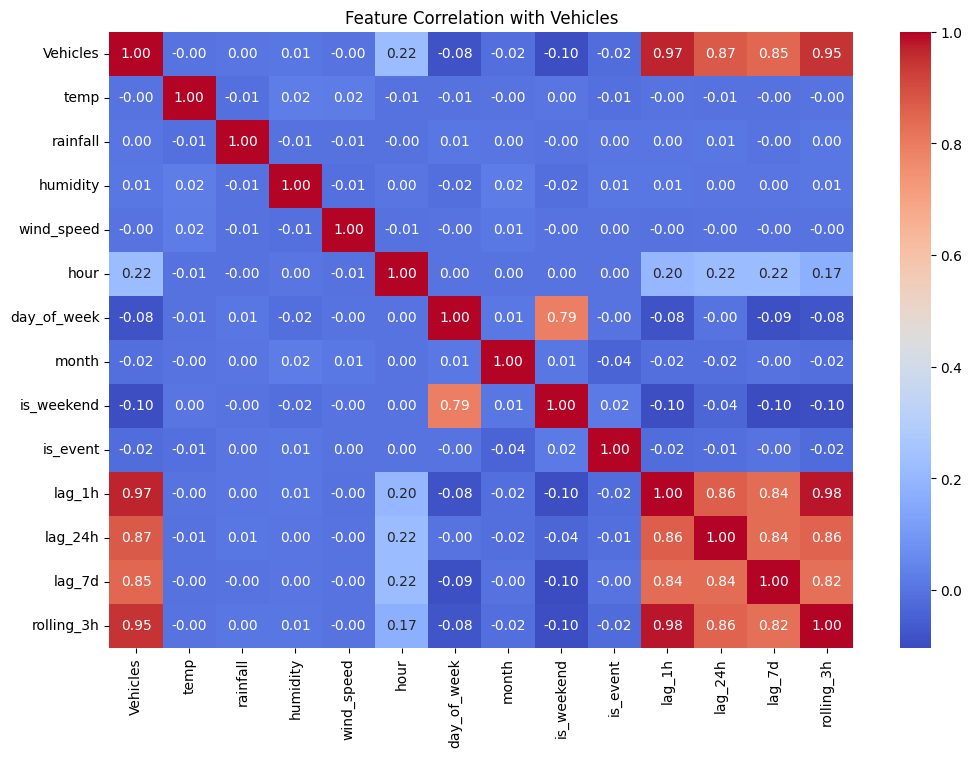

Correlation with Vehicles:
 Vehicles       1.000000
lag_1h         0.968425
rolling_3h     0.946592
lag_24h        0.872870
lag_7d         0.845433
hour           0.219938
humidity       0.005093
rainfall       0.001873
wind_speed    -0.002293
temp          -0.002690
month         -0.016758
is_event      -0.020271
day_of_week   -0.084059
is_weekend    -0.096628
Name: Vehicles, dtype: float64


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric features for correlation
numeric_cols = ['Vehicles','temp','rainfall','humidity','wind_speed','hour','day_of_week','month','is_weekend','is_event','lag_1h','lag_24h','lag_7d','rolling_3h']
corr = merged_df[numeric_cols].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation with Vehicles')
plt.show()

print("Correlation with Vehicles:\n", corr['Vehicles'].sort_values(ascending=False))

        Feature  Importance
10       lag_1h    0.938602
5          hour    0.016857
13   rolling_3h    0.009491
11      lag_24h    0.007727
12       lag_7d    0.006504
4    wind_speed    0.004615
3      humidity    0.004346
1          temp    0.004270
7         month    0.002386
0      Junction    0.002202
6   day_of_week    0.001782
2      rainfall    0.000869
8    is_weekend    0.000321
9      is_event    0.000027


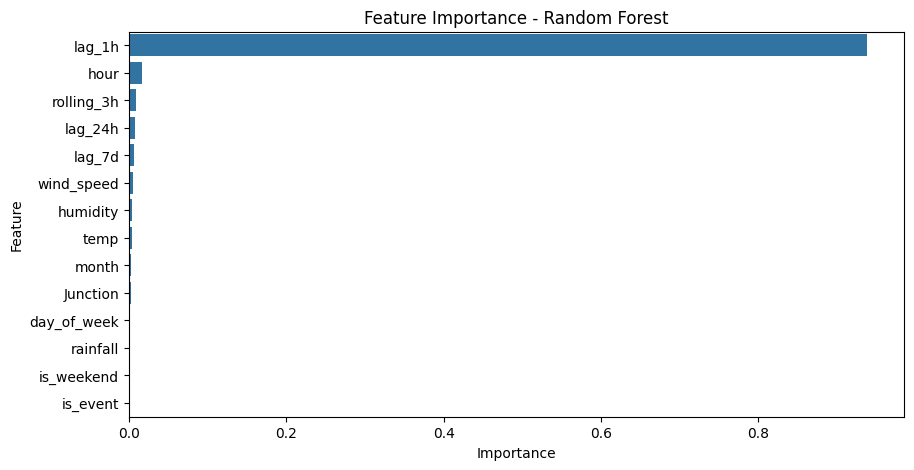

Saved featured_data.csv with shape: (48120, 22)


In [17]:
from sklearn.ensemble import RandomForestRegressor

# Features and target
features = ['Junction','temp','rainfall','humidity','wind_speed','hour','day_of_week','month','is_weekend','is_event','lag_1h','lag_24h','lag_7d','rolling_3h']
X = merged_df[features]
y = merged_df['Vehicles']

# For Junction categorical -> make dummy or numeric, its already numeric 1-4
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Importance
importance = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_})
importance = importance.sort_values('Importance', ascending=False)

print(importance)

plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Feature Importance - Random Forest')
plt.show()

# Save final dataset for Task 3
merged_df.to_csv('featured_data.csv', index=False)
print("Saved featured_data.csv with shape:", merged_df.shape)

        Feature  Importance
10       lag_1h    0.938602
5          hour    0.016857
13   rolling_3h    0.009491
11      lag_24h    0.007727
12       lag_7d    0.006504
4    wind_speed    0.004615
3      humidity    0.004346
1          temp    0.004270
7         month    0.002386
0      Junction    0.002202
6   day_of_week    0.001782
2      rainfall    0.000869
8    is_weekend    0.000321
9      is_event    0.000027


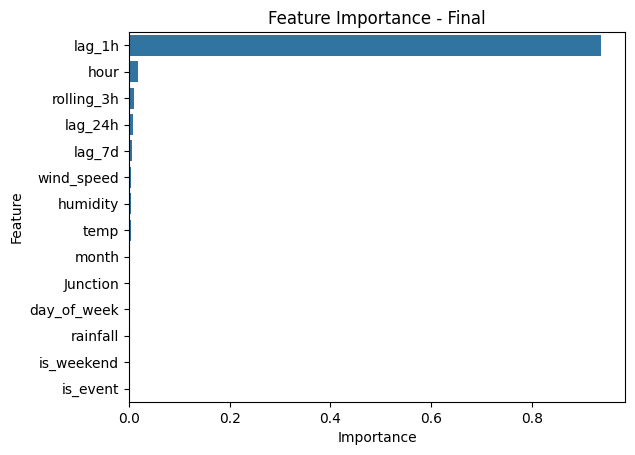

Saved featured_data.csv


In [18]:
# Fix rolling to make it more accurate
merged_df = merged_df.sort_values(['Junction','DateTime'])
merged_df['rolling_3h'] = merged_df.groupby('Junction')['Vehicles'].transform(lambda x: x.shift(1).rolling(3).mean())
merged_df['rolling_3h'] = merged_df['rolling_3h'].fillna(merged_df['Vehicles'].mean())

# Re-run importance quickly
from sklearn.ensemble import RandomForestRegressor
features = ['Junction','temp','rainfall','humidity','wind_speed','hour','day_of_week','month','is_weekend','is_event','lag_1h','lag_24h','lag_7d','rolling_3h']
X = merged_df[features]
y = merged_df['Vehicles']
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
importance = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_}).sort_values('Importance', ascending=False)
print(importance)
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Feature Importance - Final')
plt.show()
merged_df.to_csv('featured_data.csv', index=False)
print("Saved featured_data.csv")

    Feature  Importance
     lag_1h    0.938602
       hour    0.016857
 rolling_3h    0.009491
    lag_24h    0.007727
     lag_7d    0.006504
 wind_speed    0.004615
   humidity    0.004346
       temp    0.004270
      month    0.002386
   Junction    0.002202
day_of_week    0.001782
   rainfall    0.000869
 is_weekend    0.000321
   is_event    0.000027


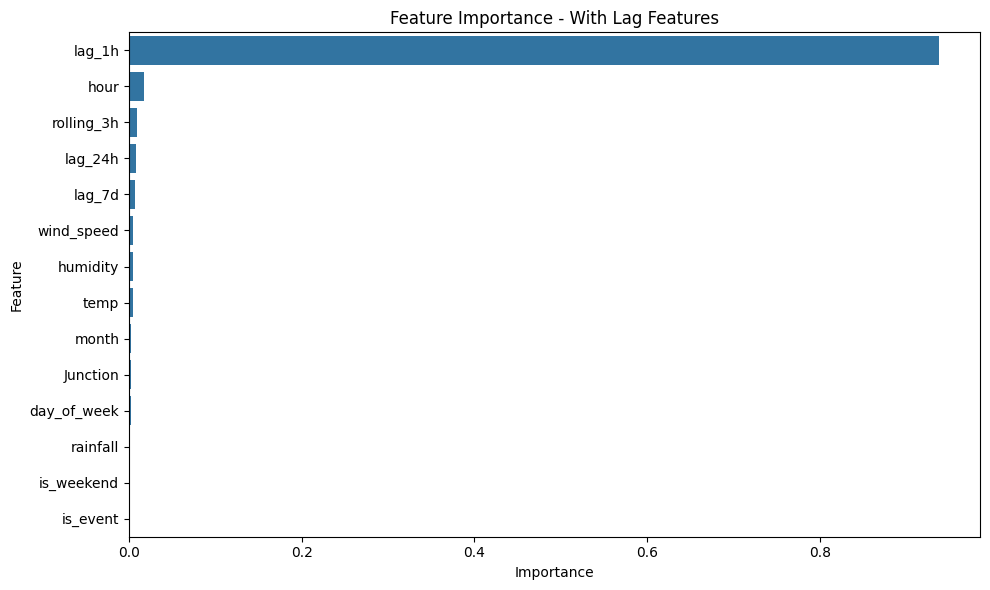

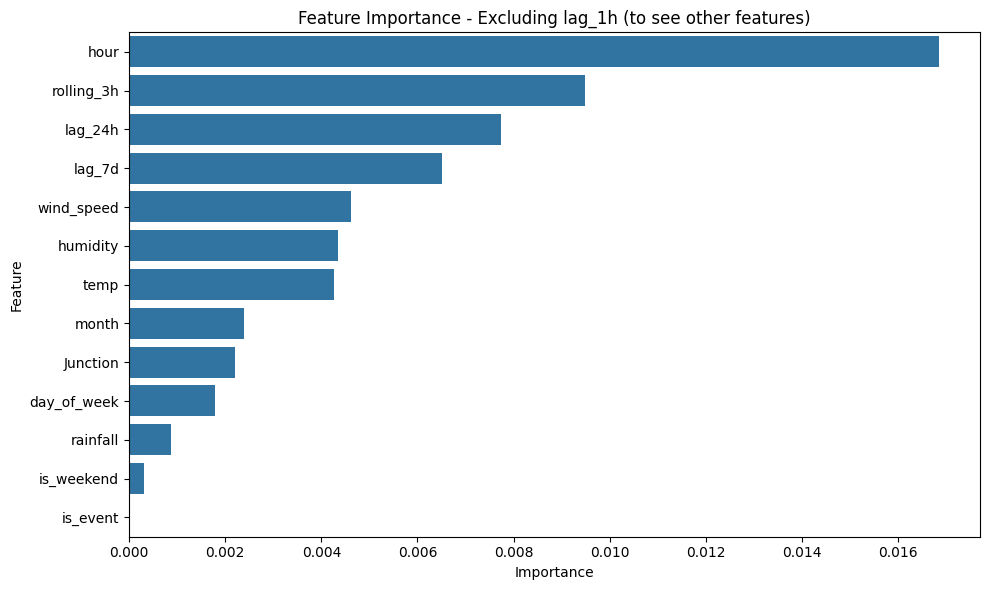

In [19]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.ensemble import RandomForestRegressor

features = ['Junction','temp','rainfall','humidity','wind_speed','hour','day_of_week','month','is_weekend','is_event','lag_1h','lag_24h','lag_7d','rolling_3h']
X = merged_df[features]
y = merged_df['Vehicles']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

importance = pd.DataFrame({'Feature': features, 'Importance': model.feature_importances_})
importance = importance.sort_values('Importance', ascending=False)
print(importance.to_string(index=False))

# --- Plot 1: With all features (your original) ---
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance)
plt.title('Feature Importance - With Lag Features')
plt.tight_layout()
plt.show()

# --- Plot 2: WITHOUT lag_1h for better visibility (for report) ---
importance_no_lag1 = importance[importance['Feature']!= 'lag_1h']
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_no_lag1)
plt.title('Feature Importance - Excluding lag_1h (to see other features)')
plt.tight_layout()
plt.show()